In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [2]:
# Load Dataset

train = pd.read_csv("../data/train.csv")

stores = pd.read_csv("../data/stores.csv")

features = pd.read_csv("../data/features.csv")

In [3]:
#Study Dataset - train.csv

train.head()
train.info()
train.describe()
train.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  str    
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), str(1)
memory usage: 13.3 MB


Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64

In [4]:
#Study Dataset - features.csv

features.head()
features.info()
features.describe()
features.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   str    
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), str(1)
memory usage: 712.0 KB


Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64

In [5]:
#Study Dataset - stores.csv

stores.head()
stores.info()
stores.describe()
stores.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Store   45 non-null     int64
 1   Type    45 non-null     str  
 2   Size    45 non-null     int64
dtypes: int64(2), str(1)
memory usage: 1.2 KB


Store    0
Type     0
Size     0
dtype: int64

In [12]:
#Merge Dataset

df = pd.merge(train, stores, on="Store", how="left")
print(df.shape)

df = pd.merge(df, features, on=["Store", "Date"], how="left")
print(df.shape)

df.head()

(421570, 7)
(421570, 17)


,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [ ]:
#Basic EDA

#unique stores
df["Store"].nunique()

45

In [18]:
#date range 

print(df["Date"].min())

print(df["Date"].max())

2010-02-05
2012-10-26


In [19]:
#total sales

df["Weekly_Sales"].sum()

np.float64(6737218987.110001)

In [20]:
#average sales

df["Weekly_Sales"].mean()

np.float64(15981.258123467042)

In [21]:
#highest selling store

store_sales = df.groupby("Store")["Weekly_Sales"].sum()

highest_store = store_sales.idxmax()
highest_sales = store_sales.max()

print("Highest Selling Store:", highest_store)
print("Total Sales:", highest_sales)

Highest Selling Store: 20
Total Sales: 301397792.46


In [22]:
#lowest selling store

lowest_store = store_sales.idxmin()
lowest_sales = store_sales.min()

print("Lowest Selling Store:", lowest_store)
print("Total Sales:", lowest_sales)

Lowest Selling Store: 33
Total Sales: 37160221.96


In [25]:
# top departments

top_departments = (
    df.groupby("Dept")["Weekly_Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_departments)

Dept
92    4.839433e+08
95    4.493202e+08
38    3.931181e+08
72    3.057252e+08
90    2.910685e+08
40    2.889360e+08
2     2.806112e+08
91    2.167817e+08
13    1.973216e+08
8     1.942808e+08
Name: Weekly_Sales, dtype: float64


In [26]:
#monthly sales

df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.month
monthly_sales = df.groupby("Month")["Weekly_Sales"].sum()

print(monthly_sales)

Month
1     3.325984e+08
2     5.687279e+08
3     5.927859e+08
4     6.468598e+08
5     5.571256e+08
6     6.226299e+08
7     6.500010e+08
8     6.130902e+08
9     5.787612e+08
10    5.847848e+08
11    4.130157e+08
12    5.768386e+08
Name: Weekly_Sales, dtype: float64


In [27]:
#GRAPHS

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

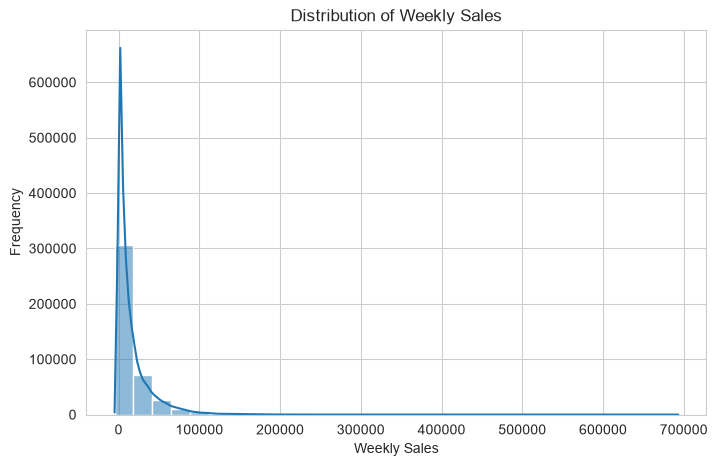

In [28]:
#Histogram (Distribution of Weekly Sales)

plt.figure(figsize=(8,5))
sns.histplot(df["Weekly_Sales"], bins=30, kde=True)

plt.title("Distribution of Weekly Sales")
plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")
plt.show()

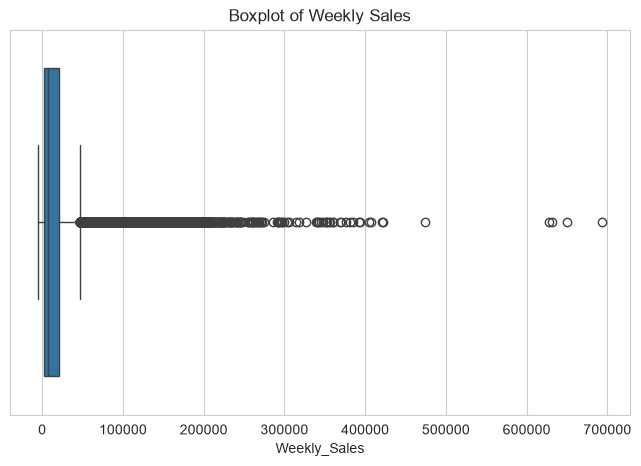

In [29]:
#Boxplot (Detect Outliers)

plt.figure(figsize=(8,5))
sns.boxplot(x=df["Weekly_Sales"])

plt.title("Boxplot of Weekly Sales")
plt.show()

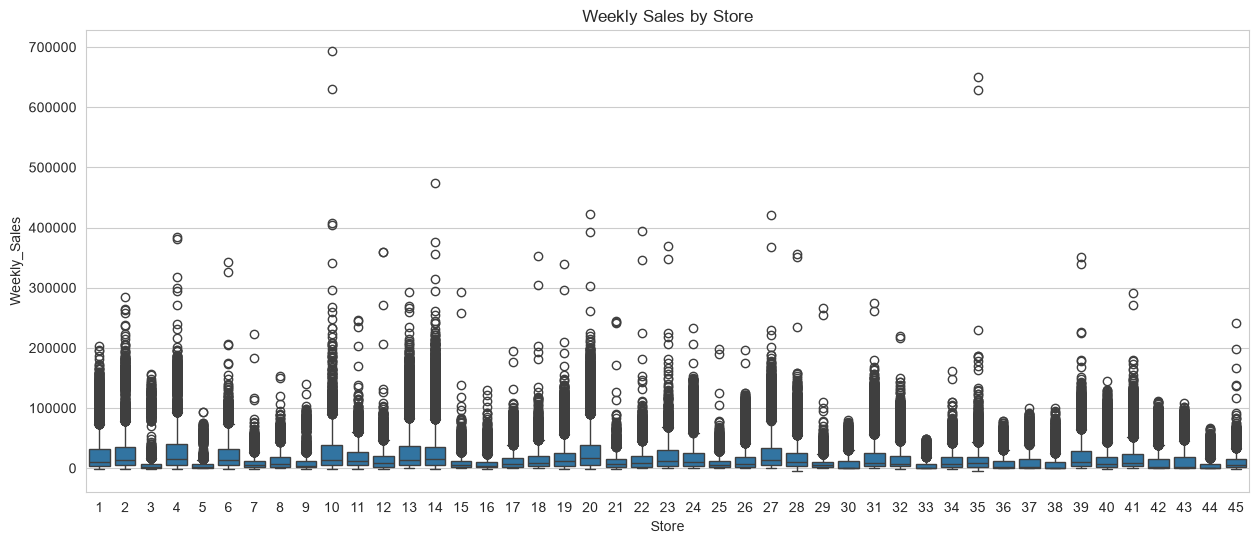

In [30]:
plt.figure(figsize=(15,6))
sns.boxplot(x="Store", y="Weekly_Sales", data=df)

plt.title("Weekly Sales by Store")
plt.show()

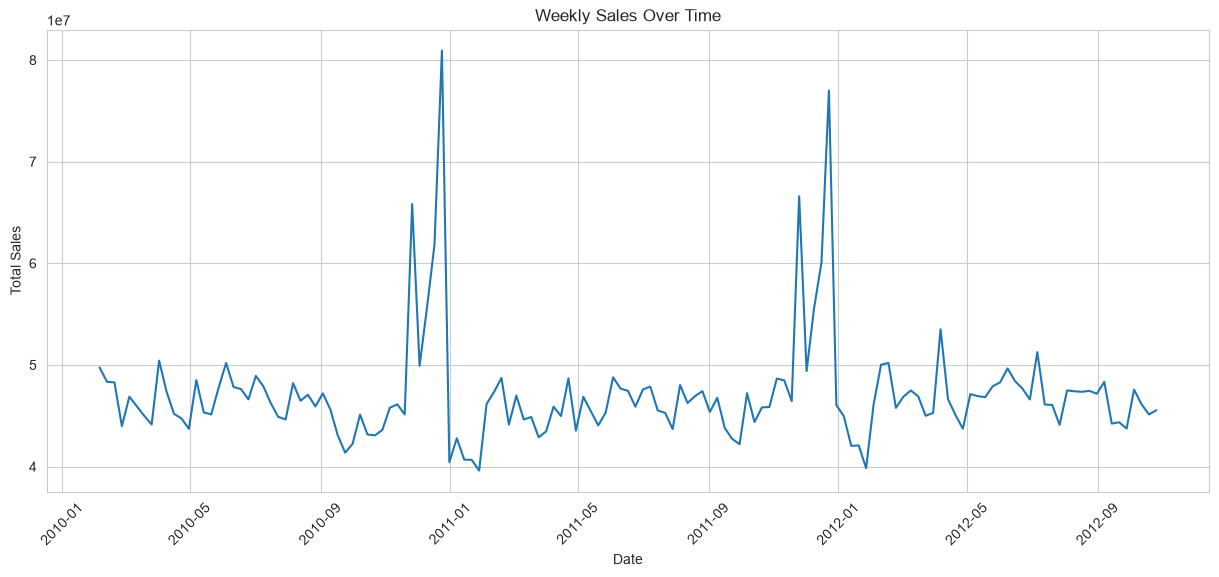

In [31]:
#Line Plot (Monthly Sales Trend)

df["Date"] = pd.to_datetime(df["Date"])
monthly_sales = df.groupby("Date")["Weekly_Sales"].sum()
plt.figure(figsize=(15,6))
plt.plot(monthly_sales.index, monthly_sales.values)

plt.title("Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

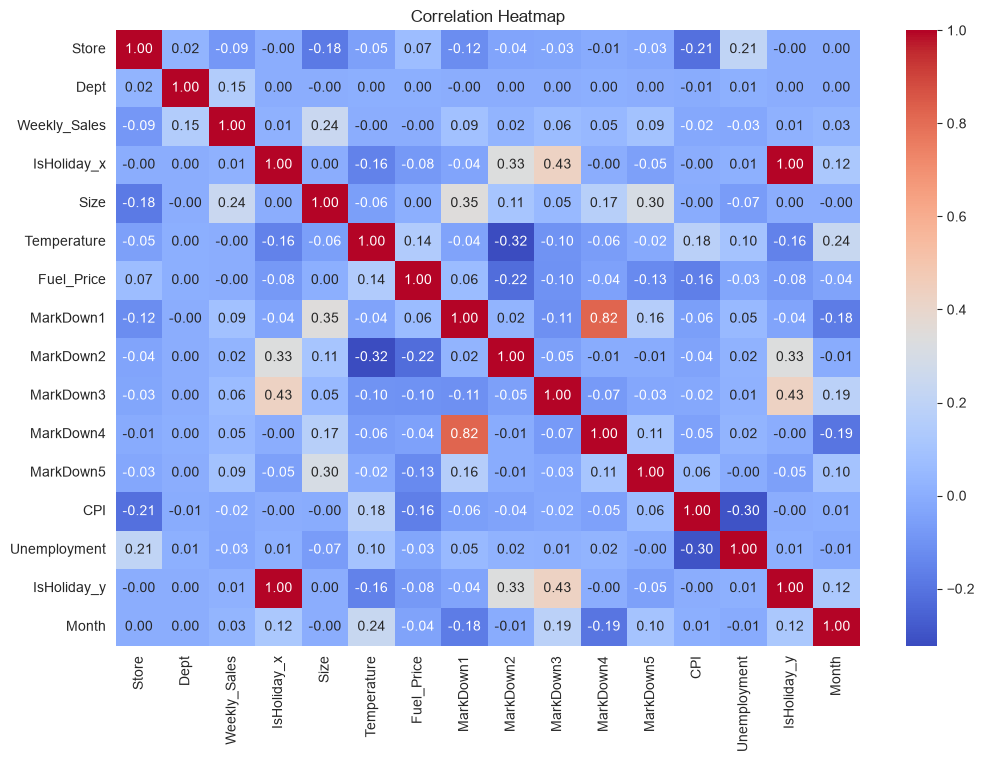

In [32]:
#Heatmap (Correlation Heatmap)

corr = df.corr(numeric_only=True)
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

In [33]:
#Correlation Matrix

corr = df.corr(numeric_only=True)

print(corr)

                 Store      Dept  Weekly_Sales  IsHoliday_x      Size  \
Store         1.000000  0.024004     -0.085195    -0.000548 -0.182881   
Dept          0.024004  1.000000      0.148032     0.000916 -0.002966   
Weekly_Sales -0.085195  0.148032      1.000000     0.012774  0.243828   
IsHoliday_x  -0.000548  0.000916      0.012774     1.000000  0.000593   
Size         -0.182881 -0.002966      0.243828     0.000593  1.000000   
Temperature  -0.050097  0.004437     -0.002312    -0.155949 -0.058313   
Fuel_Price    0.065290  0.003572     -0.000120    -0.078281  0.003361   
MarkDown1    -0.119588 -0.002426      0.085251    -0.035586  0.345673   
MarkDown2    -0.035173  0.000290      0.024130     0.334818  0.108827   
MarkDown3    -0.031556  0.001784      0.060385     0.427960  0.048913   
MarkDown4    -0.009941  0.004257      0.045414    -0.000562  0.168196   
MarkDown5    -0.026634  0.000109      0.090362    -0.053719  0.304575   
CPI          -0.211088 -0.007477     -0.020921    -

In [34]:
#Missing Value Plot

missing = df.isnull().sum()

print(missing)

Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday_x          0
Type                 0
Size                 0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
IsHoliday_y          0
Month                0
dtype: int64


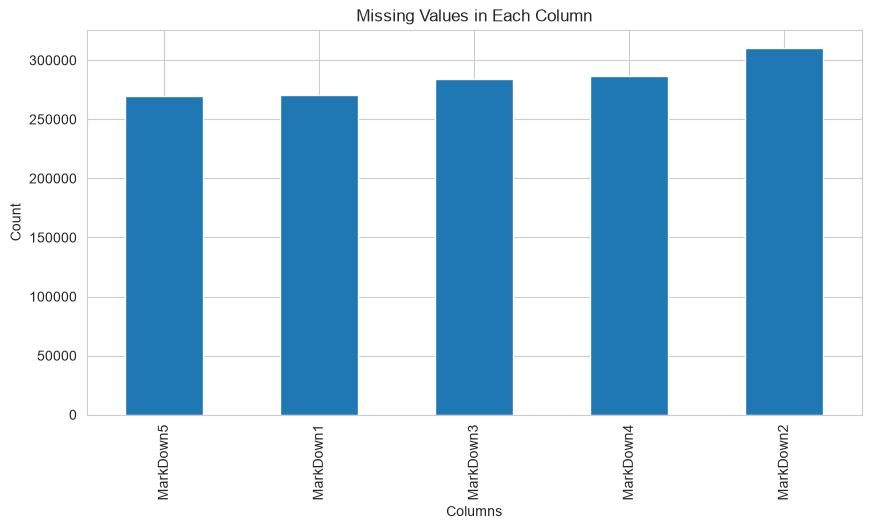

In [36]:
missing = df.isnull().sum()

missing = missing[missing > 0]

plt.figure(figsize=(10,5))
missing.sort_values().plot(kind="bar")

plt.title("Missing Values in Each Column")
plt.xlabel("Columns")
plt.ylabel("Count")
plt.show()